In [7]:
#202012349 박성윤
# 매년 점점 더 더워진다는 생각이 들어 시간이 지날수록 여름철 날씨의 변화에 대해 
# 알아봐야겠다는 생각이 들게되었다.

#첫번째 목표) 기상청의 2014~2023년 여름철 온도 데이터를 분석해서 여름철 평균기온의 변화 파악
#두번째 목표) 대한민국 온실가스 배출량과 여름철 평균기온 사이의 상관관계를 분석 및 예측 모델링

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import tensorflow as tf

#module 숫자 7개
#pandas, numpy, matplotlib, tensorflow, seaborn, stats : 3가지 이상 함수 사용
#약 32개 함수 사용
#창조적 함수, tensorflow함수들

In [9]:
#기상청의 2014~2022년 온도 CSV 파일로부터 데이터 불러오기 및 불필요한 행, 열 제거
data = pd.read_csv("C:/Users/psyreo/Desktop/data.csv", encoding='euc-kr', skiprows = 10) #pandas(1/3), csv데이터사용
df = data.drop(['Unnamed: 0','Unnamed: 1','지점번호','지점명'],axis=1) #pandas(2/3)
df['월'] = pd.to_datetime(df['일시'], format='%b-%y').dt.month 
#pandas(3/3) 
#to_datetime(날짜 정보가 문자열로 되어있어서 실제 날짜 형식으로 변경)- (창조적함수)
summerdf = df[(df['월'] >= 6) & (df['월'] <= 8)] #여름을 6월~8월로 설정하였습니다.
summerdf['연도'] = pd.to_datetime(df['일시'], format='%b-%y').dt.year
summerdf.head()

C:\Users\psyreo\AppData\Local\Temp\ipykernel_20172\1685311313.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summerdf['연도'] = pd.to_datetime(df['일시'], format='%b-%y').dt.year


,일시,평균기온(℃),평균최고기온(℃),최고기온(℃),최고기온일자,평균최저기온(℃),최저기온(℃),최저기온일자,월,연도
5,Jun-14,23.1,27.8,31.1,2014-06-06,19.7,17.3,2014-06-12,6,2014
6,Jul-14,26.1,30.6,34.4,2014-07-31,22.9,19.1,2014-07-24,7,2014
7,Aug-14,25.2,29.0,35.8,2014-08-02,22.1,18.3,2014-08-11,8,2014
17,Jun-15,23.6,29.5,34.9,2015-06-10,18.9,15.6,2015-06-21,6,2015
18,Jul-15,25.8,30.0,36.0,2015-07-11,22.6,18.2,2015-07-04,7,2015


In [37]:
#여름철 월별 평균기온의 기초통계량
mu = np.mean(summerdf['평균기온(℃)']) #평균 numpy(1/3)
var_temp = np.var(summerdf['평균기온(℃)']) #분산 numpy(2/3)
sigma = np.std(summerdf['평균기온(℃)']) #표준편차 numpy(3/3)
mode_temp = stats.mode(summerdf['평균기온(℃)']).mode[0] #scipy(1/3) - 최빈값

print("mean:", mu)
print("var:", var_temp)
print("std:", sigma)
print("최빈값:", mode_temp)

mean: 25.473333333333336
var: 3.280622222222221
std: 1.8112488018552892
최빈값: 25.9


C:\Users\psyreo\AppData\Local\Temp\ipykernel_20172\4263296663.py:5: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode_temp = stats.mode(summerdf['평균기온(℃)']).mode[0] #scipy(1/3) - 최빈값


C:\Users\psyreo\AppData\Local\Temp\ipykernel_20172\81185310.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  summer_months = summerdf[df['월'].isin([6, 7, 8])] #isin - 일치하는 값 추출


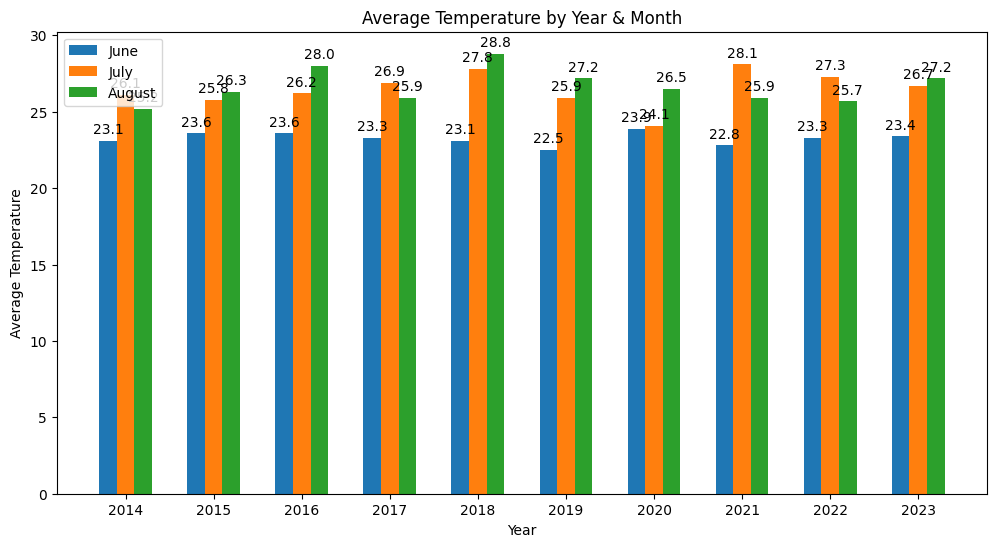

In [39]:
# 연도별-월별 평균온도 분포를 알아보기 위해
# 막대그래프 그리기

summer_months = summerdf[df['월'].isin([6, 7, 8])] #isin - 일치하는 값 추출

# 연도별로 6, 7, 8월 평균기온을 추출
summer_avg = summer_months.pivot(index='연도', columns='월', values='평균기온(℃)')
fig, ax = plt.subplots(figsize=(12, 6)) #matplotlib(1/3)

# 막대 위치 설정
bar_width = 0.2
index = np.arange(len(summer_avg))

# 각 월별 막대 추가
bar1 = ax.bar(index - bar_width, summer_avg[6], bar_width, label='June') #matplotlib(2/3)
bar2 = ax.bar(index, summer_avg[7], bar_width, label='July')
bar3 = ax.bar(index + bar_width, summer_avg[8], bar_width, label='August')


ax.set_xlabel('Year') #matplotlib(3/3)
ax.set_ylabel('Average Temperature')
ax.set_title('Average Temperature by Year & Month')
ax.set_xticks(index)
ax.set_xticklabels(summer_avg.index)
ax.legend()

# 값을 알아보기 쉽게 막대 위에 값 표시(사용자 정의 함수) 
# plt.bar가 아닌 fig, ax 변수 사용했기 때문
def labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate('{}'.format(round(height, 2)), #annotate - 텍스트 추가
                    xy=(bar.get_x() + bar.get_width() / 2, height), 
                    #(bar.get_x() + bar.get_width() / 2) - 막대중앙위치
                    xytext=(0, 3),  
                    textcoords="offset points", #xytext가 xy로부터의 offset
                    ha='center', va='bottom') #가로 세로 정렬
labels(bar1)
labels(bar2)
labels(bar3)
plt.show()

C:\Users\psyreo\anaconda3\envs\tf_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


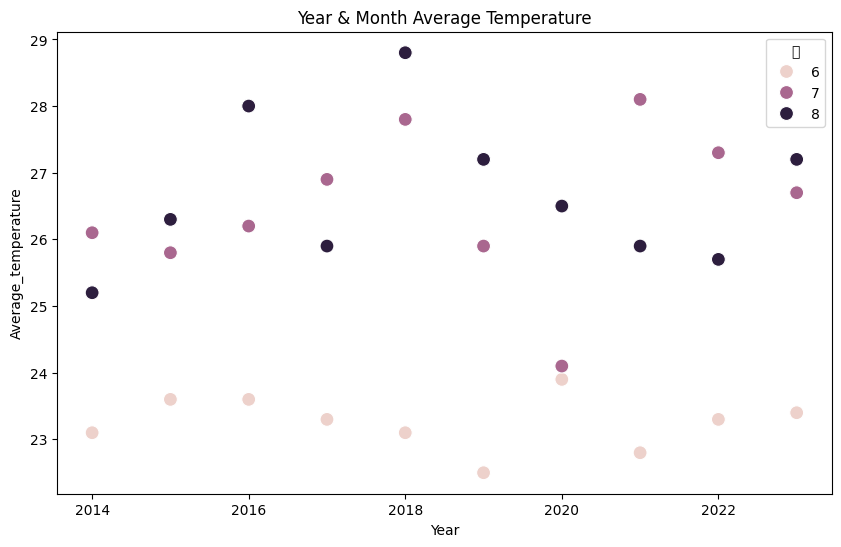

In [41]:
#규칙성이 있는지 확인하기 위해
#연도별-월별 평균온도 산점도
plt.figure(figsize=(10, 6)) 
sns.scatterplot(data=summerdf, x='연도', y='평균기온(℃)', hue='월',s=100) #seaborn(1/3)
plt.title('Year & Month Average Temperature') 
plt.xlabel('Year') #matplotlib(3/3)
plt.ylabel('Average_temperature')
plt.show()


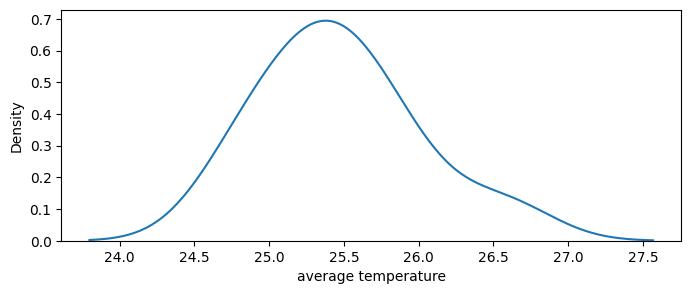

ShapiroResult(statistic=0.9477324485778809, pvalue=0.6417555212974548)


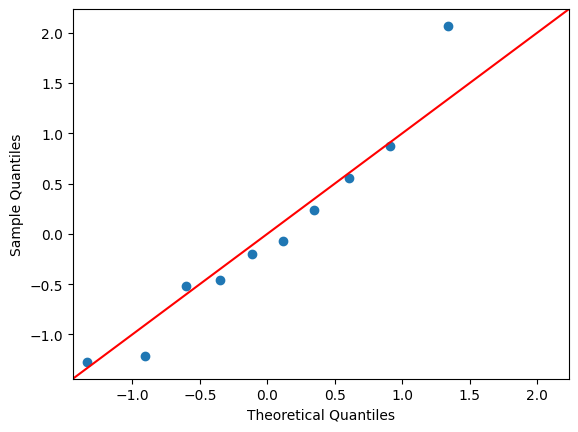

C:\Users\psyreo\anaconda3\envs\tf_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\psyreo\anaconda3\envs\tf_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\psyreo\anaconda3\envs\tf_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\psyreo\anaconda3\envs\tf_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\psyreo\anaconda3\envs\tf_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from current font.

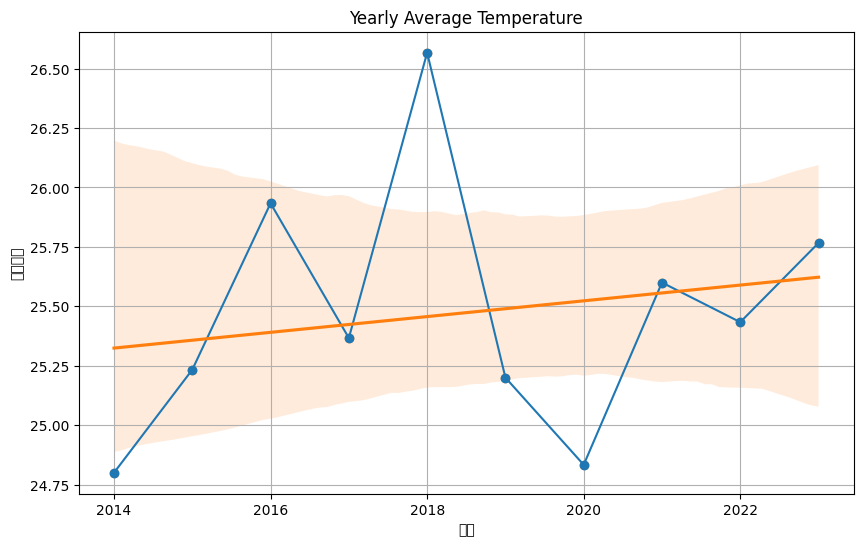

0.18966852206490015


In [49]:
#여름철 연도별 평균기온의 그래프그리기 (연도별로 기온 차이가 있는지 확인)
yearly_summeravgtemp = summerdf.groupby('연도')['평균기온(℃)'].mean().reset_index()
yearly_summeravgtemp.columns=['연도', '평균기온']

#1)커널 밀도 추정으로 시각화
plt.figure(figsize=(8,3))
sns.kdeplot(yearly_summeravgtemp['평균기온']) #seaborn(2/3)
plt.xlabel('average temperature')
plt.show()

#2)정규성 확인, 검정
ddata = (yearly_summeravgtemp['평균기온']-np.mean(yearly_summeravgtemp['평균기온']))/np.std(yearly_summeravgtemp['평균기온'],ddof=1)
sm.qqplot(ddata, line='45')
value = stats.shapiro(yearly_summeravgtemp['평균기온']) #stats(2/3)
print(value)
#검정통계량=0.94 이고 pvalue0.64>0.05 이므로 정규분포를 따른다고 할수있다.

#3)연도별 여름철 평균기온 시각화 + 회귀선
plt.figure(figsize=(10, 6))
plt.plot(yearly_summeravgtemp['연도'], yearly_summeravgtemp['평균기온'], marker='o', linestyle='-')
plt.title('Yearly Average Temperature')
plt.xlabel('Year')
plt.ylabel('Average temperature')
plt.grid(True)
sns.regplot(x=yearly_summeravgtemp['연도'],y=yearly_summeravgtemp['평균기온'],data=yearly_summeravgtemp) #seaborn(3/3)
plt.show()

#4)상관관계 분석
vvalue = stats.pearsonr(yearly_summeravgtemp['연도'], yearly_summeravgtemp['평균기온'])[0] #stats(3/3)
print(vvalue)
# 0.189로 약한 양의 상관관계, 거의없다..

In [ ]:
#2)대한민국 온실가스 배출량과 여름철 평균기온 사이의 상관관계를 분석 및 예측 모델링

In [386]:
# 이산화탄소 대한민국의 데이터만 가져오기 - 형식, 불필요한 요소 제거
data1 = pd.read_csv("C:/Users/psyreo/Desktop/data1.csv", encoding='euc-kr')
korea = data1[data1["국가별"] == "대한민국"]
korea1 = korea.T
korea1.columns = korea1.iloc[0] #열이름 설정
koreagas = korea1.drop(['국가별']).reset_index() #인덱스 초기화
koreagas.columns = ['연도', '온실가스']
koreagas['연도'] = koreagas['연도']. astype(int) #연도를 정수형으로 변환

In [436]:
# 온실가스와 온도 데이터프레임 결합(결측치 제거)
mer = pd.merge(koreagas, yearly_summeravgtemp, left_on = ['연도'], right_on = ['연도'], how = 'inner')
mer2 = mer[mer['온실가스'] != '-']
mer2

,연도,온실가스,평균기온
0,2017,710645.4,25.366667
1,2018,726977.6,26.566667
2,2019,701213.7,25.200000
3,2020,656222.9,24.833333


In [462]:
# 회귀분석 

# 온실가스와 평균기온 데이터를 TensorFlow 상수(tensor)로 변환.
greenhouse_gas_tensor = tf.constant(mer2['온실가스'], dtype=tf.float32) #tensorflow(1/3)
temperature_tensor = tf.constant(mer2['평균기온'], dtype=tf.float32)

# 1. 평균 계산
# 온실가스의 평균을 계산하고 numpy 배열로 변환
mean_greenhouse_gas = tf.reduce_mean(greenhouse_gas_tensor).numpy() #tensorflow(2/3)
# 평균 기온을 계산하고 numpy 배열로 변환.
mean_temperature = tf.reduce_mean(temperature_tensor).numpy()
# 평균값 출력
print("평균 온실가스 농도:", mean_greenhouse_gas)
print("평균 기온:", mean_temperature)


# 2. 상관 관계 계산
# 온실가스와 기온의 상관관계를 계산
correlation = tf.reduce_mean((greenhouse_gas_tensor - tf.reduce_mean(greenhouse_gas_tensor)) * (temperature_tensor - tf.reduce_mean(temperature_tensor))) / (tf.math.reduce_std(greenhouse_gas_tensor) * tf.math.reduce_std(temperature_tensor))
#출력
print("온실가스와 온도의 상관 관계:", correlation.numpy())


# 3. 선형 회귀 모델링 (사용자 정의 함수)
# 선형 회귀를 위한 TensorFlow 모델 정의
class LinearRegressionModel(tf.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        
         # 가중치와 절편을 변수로 초기화 w:가중치, b:편향
        self.w = tf.Variable(0.0) #tensorflow(3/3)
        self.b = tf.Variable(0.0)

    def __call__(self, x):
        return self.w * x + self.b 
        #선형 회귀 예측 모델 함수 만들기
        #학습이 진행되면서 w와 b값 업데이트

# 손실 함수 정의
def loss(y, y_predicted):
    return tf.reduce_mean(tf.square(y - y_predicted)) #평균 제곱 오차: 예측값과 실제값사이 차이

# 옵티마이저 정의
# 옵티마이저는 기계 학습 및 딥러닝 모델의 학습 과정에서 
# 손실 함수를 최소화하기 위해 모델의 가중치와 편향을 조정하는 알고리즘
# Adam : 1차모먼트와 2차모먼트로 학습률(업데이트 크기) 조정
optimizer = tf.optimizers.Adam(learning_rate=0.01) #가중치를 얼마나 빠르게 업데이트할지

# 모델 생성
model = LinearRegressionModel()

# 학습
for epoch in range(1000): #epoch 모델을 통해 한번에 전부 처리되는 단위, 1000번 학습
    with tf.GradientTape() as tape: 
        #그래디언트(미분값):가중치 최적화를 위해 옵티마이저에 필요한 손실함수의 기울기
        
        # 모델을 통해 예측값 계산
        y_predicted = model(greenhouse_gas_tensor) 
        #y_predicted:온실가스데이터를 통해 모델이 예측한 기온
        
        # 현재 손실 계산
        current_loss = loss(temperature_tensor, y_predicted)
        
    # 손실에 대한 가중치와 절편의 그래디언트 계산
    gradients = tape.gradient(current_loss, model.trainable_variables)
    # 옵티마이저를 사용하여 가중치와 절편 업데이트
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

# 결과
print("온실가스와 온도의 선형 회귀 결과:")
print("기울기 (가중치):", model.w.numpy())
print("절편:", model.b.numpy())

평균 온실가스 농도: 698764.9
평균 기온: 25.491667
온실가스와 온도의 상관 관계: 0.8230731
온실가스와 온도의 선형 회귀 결과:
기울기 (가중치): 3.6457943e-05
절편: 0.0003089306


In [ ]:
#결과
#1) 기상청의 2014~2023년 여름철 온도 데이터를 분석해서 여름철 평균기온의 변화 파악
# -> 연도와 평균기온의 상관관계가 미미해서 큰 관계가 없다고 봐도 무방하다.
# 상관관계가 거의 없어서 다른 목표를 생각하게 되었다.

#2) 대한민국 온실가스 배출량과 여름철 평균기온 사이의 상관관계를 분석 및 예측 모델링
# ->평균 온실가스 농도: 698764.9(천톤) 7억톤
# ->평균 기온: 25.491667
# ->온실가스와 온도의 상관 관계: 0.8230731
# ->온실가스와 온도의 선형 회귀 결과:
# ->기울기 (가중치): 3.6457943e-05
# ->절편: 0.0003089306